# 01b — Contrôle qualité des métriques générées

À exécuter après le notebook `01_generer_csv_<corpus>.ipynb`. Le corpus est
sélectionné dans la cellule de configuration ; aucun CSV d'un autre corpus n'est
mélangé automatiquement.


## 1. Configuration


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from metric_registry import get_dataset
from pipeline_utils import detect_project_dir, metric_inventory, aggregate_metrics

PROJECT_DIR = detect_project_dir()
DATASET = "Mirabelle"  # "Mirabelle", "Nowledgeable" ou "Progsnap2"
JOIN_MODE = "outer"

SPEC = get_dataset(DATASET)
CSV_DIR = SPEC.csv_dir(PROJECT_DIR)
print("Corpus :", DATASET)
print("CSV    :", CSV_DIR)


Corpus : Mirabelle
CSV    : C:\Users\chris\Desktop\Code\TracesPresenter\Traces_presenter\Jupyter\Chaine_nettoyee_2026-08-15\Chaine_nettoyee\csv\Mirabelle


## 2. Inventaire


In [10]:
inventory_df = metric_inventory(CSV_DIR)
if inventory_df.empty:
    raise FileNotFoundError(f"Aucune métrique dans {CSV_DIR}. Exécutez d'abord le notebook 01 correspondant.")
display(inventory_df)


,fichier,statut,lignes,colonnes,variables
0,attempts_to_first_success.csv,ok,44,2,AttemptsToFirstSuccess
1,code_change_magnitude.csv,ok,42,2,CodeChangeMagnitude
2,error_quotient.csv,ok,42,2,ErrorQuotient
3,error_quotient_fe.csv,ok,42,2,ErrorQuotient_FE
4,exception_run_ratio.csv,ok,45,2,ExceptionTestRunRatio
5,failed_run_ratio.csv,ok,45,2,FailedTestRunRatio
6,first_attempt_success_rate.csv,ok,45,2,FirstAttemptSuccessRate
7,function_coverage.csv,ok,49,2,FunctionCoverage
8,productive_transition_rate.csv,ok,37,2,ProductiveTransitionRate
9,red.csv,ok,42,2,RED


## 3. Agrégation par étudiant


In [11]:
features, load_report = aggregate_metrics(CSV_DIR, join_mode=JOIN_MODE)
display(load_report)
print(f"Table agrégée : {features.shape[0]} étudiant(s) × {features.shape[1]-1} métrique(s)")
display(features.head())


,fichier,statut,raison,lignes,variables
0,attempts_to_first_success.csv,chargé,,44,AttemptsToFirstSuccess
1,code_change_magnitude.csv,chargé,,42,CodeChangeMagnitude
2,error_quotient.csv,chargé,,42,ErrorQuotient
3,error_quotient_fe.csv,chargé,,42,ErrorQuotient_FE
4,exception_run_ratio.csv,chargé,,45,ExceptionTestRunRatio
5,failed_run_ratio.csv,chargé,,45,FailedTestRunRatio
6,first_attempt_success_rate.csv,chargé,,45,FirstAttemptSuccessRate
7,function_coverage.csv,chargé,,49,FunctionCoverage
8,productive_transition_rate.csv,chargé,,37,ProductiveTransitionRate
9,red.csv,chargé,,42,RED


Table agrégée : 49 étudiant(s) × 16 métrique(s)


,SubjectID,AttemptsToFirstSuccess,CodeChangeMagnitude,ErrorQuotient,ErrorQuotient_FE,ExceptionTestRunRatio,FailedTestRunRatio,FirstAttemptSuccessRate,FunctionCoverage,ProductiveTransitionRate,RED,RED_FE,SessionCount,SessionSpanMinutes,TestPassRate,TimeToFirstSuccess,UnchangedRerunRatio
0,apercevra.conter,2.142857,0.025558,0.747475,0.777778,0.0,0.888889,0.7500,8,0.166667,0.545833,0.680556,5.0,75.140033,0.917981,0.895700,0.000000
1,auspices.heurtoir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,avereront.vouees,1.312500,0.028228,0.117647,0.117647,0.0,0.352941,0.8125,16,0.600000,0.058824,0.058824,6.0,75.379950,0.988251,0.460919,0.000000
3,avertis.cormoran,1.000000,NaN,NaN,NaN,0.0,0.000000,1.0000,1,NaN,NaN,NaN,1.0,0.000000,1.000000,0.000000,NaN
4,avouait.happes,1.181818,0.036718,0.132231,0.181818,0.0,0.416667,0.7500,12,0.600000,0.000000,0.121212,6.0,74.052867,0.980892,0.228205,0.083333


## 4. Valeurs manquantes et distributions


,variable,pct_manquant
0,ProductiveTransitionRate,24.489796
1,CodeChangeMagnitude,14.285714
2,ErrorQuotient_FE,14.285714
3,ErrorQuotient,14.285714
4,RED,14.285714
5,RED_FE,14.285714
6,UnchangedRerunRatio,12.244898
7,AttemptsToFirstSuccess,10.204082
8,TimeToFirstSuccess,10.204082
9,FirstAttemptSuccessRate,8.163265


,count,mean,std,min,25%,50%,75%,max
AttemptsToFirstSuccess,44.0,1.454314,0.592241,1.000000,1.000000,1.258333,1.599265,3.666667
CodeChangeMagnitude,42.0,0.043875,0.056268,0.000493,0.017099,0.028463,0.042840,0.322824
ErrorQuotient,42.0,0.252243,0.253313,0.000000,0.078525,0.168882,0.392774,1.000000
ErrorQuotient_FE,42.0,0.262987,0.258154,0.000000,0.078525,0.196154,0.417395,1.000000
ExceptionTestRunRatio,45.0,0.206493,0.383310,0.000000,0.000000,0.000000,0.058824,1.000000
FailedTestRunRatio,45.0,0.547630,0.306505,0.000000,0.352941,0.511628,0.785714,1.000000
FirstAttemptSuccessRate,45.0,0.739209,0.170278,0.000000,0.636364,0.764706,0.833333,1.000000
FunctionCoverage,49.0,9.857143,5.838093,0.000000,5.000000,11.000000,13.000000,24.000000
ProductiveTransitionRate,37.0,0.379376,0.244933,0.000000,0.227273,0.416667,0.529412,1.000000
RED,42.0,0.146279,0.155081,0.000000,0.005208,0.097619,0.226590,0.545833


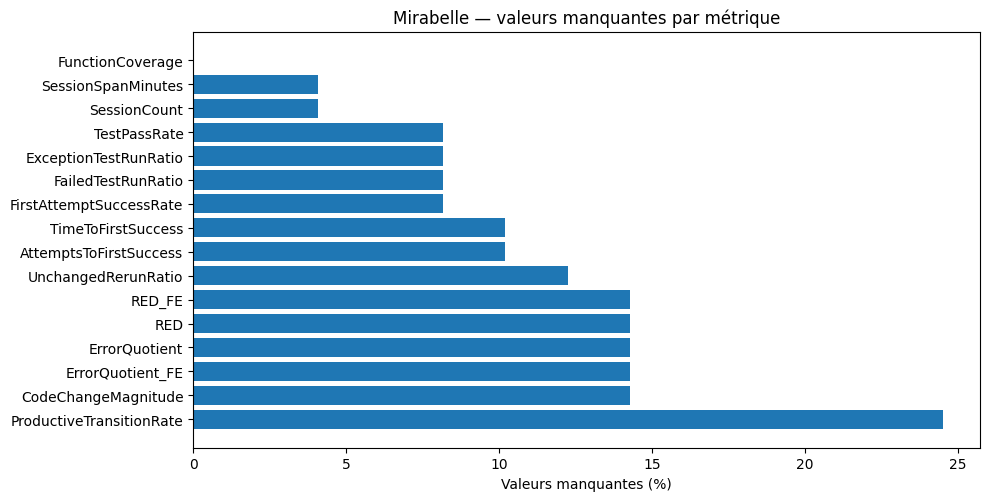

In [12]:
metric_cols = [c for c in features.columns if c != "SubjectID"]
for col in metric_cols:
    features[col] = pd.to_numeric(features[col], errors="coerce")

missing = (
    features[metric_cols].isna().mean().mul(100)
    .sort_values(ascending=False)
    .rename("pct_manquant").reset_index().rename(columns={"index": "variable"})
)
display(missing)

display(features[metric_cols].describe().T)

plt.figure(figsize=(10, max(4, 0.32 * len(missing))))
plt.barh(missing["variable"], missing["pct_manquant"])
plt.xlabel("Valeurs manquantes (%)")
plt.title(f"{DATASET} — valeurs manquantes par métrique")
plt.tight_layout()
plt.show()
